In [1]:
# =========================================
# 06D_architecture_specific_classification.ipynb
# Architecture-specific extreme classification
# =========================================
import os
import json
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

pd.set_option("display.max_columns", 300)

WORK_DIR = r"C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026"

X_FILE = os.path.join(WORK_DIR, "interim", "X_features.parquet")
Y_FILE = os.path.join(WORK_DIR, "interim", "y_target.parquet")
GROUP_FILE = os.path.join(WORK_DIR, "interim", "groups.parquet")

REPORT_DIR = os.path.join(WORK_DIR, "reports")
META_DIR = os.path.join(WORK_DIR, "metadata")
ARTIFACT_DIR = os.path.join(WORK_DIR, "artifacts", "06D_architecture_cls")

for p in [REPORT_DIR, META_DIR, ARTIFACT_DIR]:
    os.makedirs(p, exist_ok=True)

In [2]:
X = pd.read_parquet(X_FILE)
y = pd.read_parquet(Y_FILE)["T80_log1p"].copy()
groups = pd.read_parquet(GROUP_FILE)["Ref_DOI_number"].copy()

assert len(X) == len(y) == len(groups)

print("X shape:", X.shape)
print("Unique DOI:", groups.nunique())

X shape: (1835, 77)
Unique DOI: 964


In [3]:
def run_grouped_cls(X, y_bin, groups, models, n_repeats=30):
    scores = []

    gss = GroupShuffleSplit(
        n_splits=n_repeats,
        test_size=0.2,
        random_state=SEED
    )

    for rep, (tr, te) in enumerate(gss.split(X, y_bin, groups), start=1):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y_bin.iloc[tr], y_bin.iloc[te]

        for name, model in models.items():
            model.fit(Xtr, ytr)
            prob = model.predict_proba(Xte)[:, 1]
            pred = (prob >= 0.5).astype(int)

            m = eval_binary(yte, prob, pred)
            m["model"] = name
            m["repeat"] = rep
            scores.append(m)

    return pd.DataFrame(scores)

In [4]:
assert "is_nip" in X.columns
assert "is_pin" in X.columns

mask_nip = X["is_nip"] == 1
mask_pin = X["is_pin"] == 1

print("Total rows:", len(X))
print("NIP rows:", int(mask_nip.sum()))
print("PIN rows:", int(mask_pin.sum()))

Total rows: 1835
NIP rows: 1266
PIN rows: 567


In [5]:
def build_extreme_dataset(X, y, groups, low_q, high_q):
    q_low = y.quantile(low_q)
    q_high = y.quantile(high_q)

    keep_mask = (y <= q_low) | (y >= q_high)

    X_sub = X.loc[keep_mask].copy()
    y_sub = y.loc[keep_mask].copy()
    g_sub = groups.loc[keep_mask].copy()

    y_bin = (y_sub >= q_high).astype(int)

    return X_sub, y_bin, g_sub, q_low, q_high

In [6]:
def eval_binary(y_true, y_prob, y_pred):
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "n_test": len(y_true),
    }

def summarize(df, split, model):
    out = {"split": split, "model": model, "n_runs": len(df)}
    for m in ["roc_auc", "pr_auc", "balanced_acc", "f1"]:
        out[f"{m}_mean"] = df[m].mean()
        out[f"{m}_std"] = df[m].std(ddof=1)
    return out

In [7]:
models = {

    "logistic": Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=SEED
        ))
    ]),

    "rf": Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=4,
            min_samples_leaf=2,
            class_weight="balanced",
            n_jobs=1,
            random_state=SEED
        ))
    ]),

    "hgb": Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("clf", HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_depth=6,
            max_iter=400,
            min_samples_leaf=10,
            random_state=SEED
        ))
    ])
}

print("Models:", list(models.keys()))

Models: ['logistic', 'rf', 'hgb']


In [8]:
# --- strict architecture columns only ---
arch_feature_cols = [
    c for c in X.columns
    if (
        c in ["is_nip", "is_pin", "is_other_arch"]
        or c.startswith("architecture_family_")
    )
]

print("Architecture columns:", arch_feature_cols)

assert "is_nip" in X.columns
assert "is_pin" in X.columns

mask_nip = X["is_nip"] == 1
mask_pin = X["is_pin"] == 1

print("Total:", len(X))
print("NIP:", int(mask_nip.sum()))
print("PIN:", int(mask_pin.sum()))

Architecture columns: ['is_nip', 'is_pin', 'is_other_arch', 'architecture_family_nip', 'architecture_family_other_or_unknown', 'architecture_family_pin']
Total: 1835
NIP: 1266
PIN: 567


In [9]:
results = []

settings = [
    ("30_70", 0.30, 0.70),
    ("25_75", 0.25, 0.75),
]

for setting_name, ql, qh in settings:

    # ---------- pooled extreme dataset ----------
    X_cls, y_bin, g_cls, _, _ = build_extreme_dataset(X, y, groups, ql, qh)

    print(f"\n=== pooled_with_arch | {setting_name} ===")
    print("Rows:", len(X_cls), "DOI:", g_cls.nunique())

    # pooled WITH architecture
    df_scores = run_grouped_cls(X_cls, y_bin, g_cls, models)
    for m in df_scores["model"].unique():
        dfm = df_scores[df_scores["model"] == m]
        row = summarize(dfm, f"pooled_with_arch_{setting_name}", m)
        row["dataset"] = "pooled_with_arch"
        row["setting"] = setting_name
        row["n_rows"] = len(X_cls)
        row["n_doi"] = g_cls.nunique()
        results.append(row)

    # pooled WITHOUT architecture
    X_cls_wo_arch = X_cls.drop(columns=arch_feature_cols, errors="ignore").copy()

    print(f"\n=== pooled_without_arch | {setting_name} ===")
    print("Rows:", len(X_cls_wo_arch), "DOI:", g_cls.nunique())

    df_scores = run_grouped_cls(X_cls_wo_arch, y_bin, g_cls, models)
    for m in df_scores["model"].unique():
        dfm = df_scores[df_scores["model"] == m]
        row = summarize(dfm, f"pooled_without_arch_{setting_name}", m)
        row["dataset"] = "pooled_without_arch"
        row["setting"] = setting_name
        row["n_rows"] = len(X_cls_wo_arch)
        row["n_doi"] = g_cls.nunique()
        results.append(row)

    # ---------- nip-only ----------
    X_nip = X.loc[mask_nip].copy()
    y_nip = y.loc[mask_nip].copy()
    g_nip = groups.loc[mask_nip].copy()

    X_nip_cls, y_nip_bin, g_nip_cls, _, _ = build_extreme_dataset(X_nip, y_nip, g_nip, ql, qh)
    X_nip_cls_wo_arch = X_nip_cls.drop(columns=arch_feature_cols, errors="ignore").copy()

    print(f"\n=== nip_only | {setting_name} ===")
    print("Rows:", len(X_nip_cls_wo_arch), "DOI:", g_nip_cls.nunique())

    if g_nip_cls.nunique() >= 30:
        df_scores = run_grouped_cls(X_nip_cls_wo_arch, y_nip_bin, g_nip_cls, models)
        for m in df_scores["model"].unique():
            dfm = df_scores[df_scores["model"] == m]
            row = summarize(dfm, f"nip_only_{setting_name}", m)
            row["dataset"] = "nip_only"
            row["setting"] = setting_name
            row["n_rows"] = len(X_nip_cls_wo_arch)
            row["n_doi"] = g_nip_cls.nunique()
            results.append(row)

    # ---------- pin-only ----------
    X_pin = X.loc[mask_pin].copy()
    y_pin = y.loc[mask_pin].copy()
    g_pin = groups.loc[mask_pin].copy()

    X_pin_cls, y_pin_bin, g_pin_cls, _, _ = build_extreme_dataset(X_pin, y_pin, g_pin, ql, qh)
    X_pin_cls_wo_arch = X_pin_cls.drop(columns=arch_feature_cols, errors="ignore").copy()

    print(f"\n=== pin_only | {setting_name} ===")
    print("Rows:", len(X_pin_cls_wo_arch), "DOI:", g_pin_cls.nunique())

    if g_pin_cls.nunique() >= 30:
        df_scores = run_grouped_cls(X_pin_cls_wo_arch, y_pin_bin, g_pin_cls, models)
        for m in df_scores["model"].unique():
            dfm = df_scores[df_scores["model"] == m]
            row = summarize(dfm, f"pin_only_{setting_name}", m)
            row["dataset"] = "pin_only"
            row["setting"] = setting_name
            row["n_rows"] = len(X_pin_cls_wo_arch)
            row["n_doi"] = g_pin_cls.nunique()
            results.append(row)

summary_df = pd.DataFrame(results)
summary_df.sort_values("roc_auc_mean", ascending=False)


=== pooled_with_arch | 30_70 ===
Rows: 1120 DOI: 683

=== pooled_without_arch | 30_70 ===
Rows: 1120 DOI: 683

=== nip_only | 30_70 ===
Rows: 770 DOI: 464

=== pin_only | 30_70 ===
Rows: 349 DOI: 221

=== pooled_with_arch | 25_75 ===
Rows: 921 DOI: 564

=== pooled_without_arch | 25_75 ===
Rows: 921 DOI: 564

=== nip_only | 25_75 ===
Rows: 642 DOI: 391

=== pin_only | 25_75 ===
Rows: 284 DOI: 178


,split,model,n_runs,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_acc_mean,balanced_acc_std,f1_mean,f1_std,dataset,setting,n_rows,n_doi
19,nip_only_25_75,rf,30,0.771099,0.049651,0.741241,0.074214,0.718430,0.045790,0.717840,0.057957,nip_only,25_75,642,391
21,pin_only_25_75,logistic,30,0.765384,0.077067,0.772180,0.093524,0.676159,0.066064,0.704731,0.071105,pin_only,25_75,284,178
22,pin_only_25_75,rf,30,0.752740,0.059928,0.779330,0.086605,0.660829,0.064819,0.677555,0.074221,pin_only,25_75,284,178
18,nip_only_25_75,logistic,30,0.752667,0.055192,0.723982,0.084902,0.697483,0.044992,0.699779,0.052709,nip_only,25_75,642,391
13,pooled_with_arch_25_75,rf,30,0.752105,0.039815,0.731463,0.054386,0.687382,0.041519,0.692039,0.047156,pooled_with_arch,25_75,921,564
16,pooled_without_arch_25_75,rf,30,0.750681,0.041425,0.729550,0.057095,0.690285,0.041545,0.694286,0.045264,pooled_without_arch,25_75,921,564
1,pooled_with_arch_30_70,rf,30,0.747551,0.038018,0.721615,0.049244,0.689193,0.033735,0.697359,0.033224,pooled_with_arch,30_70,1120,683
4,pooled_without_arch_30_70,rf,30,0.746948,0.037168,0.718923,0.052005,0.685640,0.031845,0.693608,0.031625,pooled_without_arch,30_70,1120,683
7,nip_only_30_70,rf,30,0.742732,0.044301,0.711005,0.060272,0.688789,0.040915,0.703149,0.038481,nip_only,30_70,770,464
15,pooled_without_arch_25_75,logistic,30,0.742264,0.044270,0.700919,0.077913,0.691668,0.041460,0.703350,0.047045,pooled_without_arch,25_75,921,564


In [10]:
summary_path = os.path.join(REPORT_DIR, "06D_architecture_cls_summary.csv")
summary_df.to_csv(summary_path, index=False)
print("Saved:", summary_path)

print("\nTop rows:")
display(summary_df.sort_values("roc_auc_mean", ascending=False).head(20))

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\reports\06D_architecture_cls_summary.csv

Top rows:


,split,model,n_runs,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_acc_mean,balanced_acc_std,f1_mean,f1_std,dataset,setting,n_rows,n_doi
19,nip_only_25_75,rf,30,0.771099,0.049651,0.741241,0.074214,0.718430,0.045790,0.717840,0.057957,nip_only,25_75,642,391
21,pin_only_25_75,logistic,30,0.765384,0.077067,0.772180,0.093524,0.676159,0.066064,0.704731,0.071105,pin_only,25_75,284,178
22,pin_only_25_75,rf,30,0.752740,0.059928,0.779330,0.086605,0.660829,0.064819,0.677555,0.074221,pin_only,25_75,284,178
18,nip_only_25_75,logistic,30,0.752667,0.055192,0.723982,0.084902,0.697483,0.044992,0.699779,0.052709,nip_only,25_75,642,391
13,pooled_with_arch_25_75,rf,30,0.752105,0.039815,0.731463,0.054386,0.687382,0.041519,0.692039,0.047156,pooled_with_arch,25_75,921,564
16,pooled_without_arch_25_75,rf,30,0.750681,0.041425,0.729550,0.057095,0.690285,0.041545,0.694286,0.045264,pooled_without_arch,25_75,921,564
1,pooled_with_arch_30_70,rf,30,0.747551,0.038018,0.721615,0.049244,0.689193,0.033735,0.697359,0.033224,pooled_with_arch,30_70,1120,683
4,pooled_without_arch_30_70,rf,30,0.746948,0.037168,0.718923,0.052005,0.685640,0.031845,0.693608,0.031625,pooled_without_arch,30_70,1120,683
7,nip_only_30_70,rf,30,0.742732,0.044301,0.711005,0.060272,0.688789,0.040915,0.703149,0.038481,nip_only,30_70,770,464
15,pooled_without_arch_25_75,logistic,30,0.742264,0.044270,0.700919,0.077913,0.691668,0.041460,0.703350,0.047045,pooled_without_arch,25_75,921,564


In [11]:
pivot = summary_df.pivot_table(
    index=["setting", "dataset"],
    columns="model",
    values="roc_auc_mean"
)

pivot = pivot.sort_index()
print("ROC-AUC comparison table:")
pivot

ROC-AUC comparison table:


model                             hgb  logistic        rf
setting dataset                                          
25_75   nip_only             0.729695  0.752667  0.771099
        pin_only             0.692700  0.765384  0.752740
        pooled_with_arch     0.717180  0.741168  0.752105
        pooled_without_arch  0.720616  0.742264  0.750681
30_70   nip_only             0.682032  0.741998  0.742732
        pin_only             0.681321  0.720330  0.738114
        pooled_with_arch     0.690855  0.724075  0.747551
        pooled_without_arch  0.692932  0.723683  0.746948

In [12]:
pivot_path = os.path.join(REPORT_DIR, "06D_pivot_summary.csv")
pivot.to_csv(pivot_path)
print("Saved:", pivot_path)

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\reports\06D_pivot_summary.csv


In [13]:
comparison_rows = []

for setting_name in sorted(summary_df["setting"].unique()):
    df_set = summary_df[summary_df["setting"] == setting_name].copy()

    comparison_rows.append({
        "setting": setting_name,
        "best_pooled_with_arch_rf": float(
            df_set[(df_set["dataset"] == "pooled_with_arch") & (df_set["model"] == "rf")]["roc_auc_mean"].iloc[0]
        ) if len(df_set[(df_set["dataset"] == "pooled_with_arch") & (df_set["model"] == "rf")]) else None,
        "best_pooled_without_arch_rf": float(
            df_set[(df_set["dataset"] == "pooled_without_arch") & (df_set["model"] == "rf")]["roc_auc_mean"].iloc[0]
        ) if len(df_set[(df_set["dataset"] == "pooled_without_arch") & (df_set["model"] == "rf")]) else None,
        "best_nip_rf": float(
            df_set[(df_set["dataset"] == "nip_only") & (df_set["model"] == "rf")]["roc_auc_mean"].iloc[0]
        ) if len(df_set[(df_set["dataset"] == "nip_only") & (df_set["model"] == "rf")]) else None,
        "best_pin_rf": float(
            df_set[(df_set["dataset"] == "pin_only") & (df_set["model"] == "rf")]["roc_auc_mean"].iloc[0]
        ) if len(df_set[(df_set["dataset"] == "pin_only") & (df_set["model"] == "rf")]) else None,
    })

comparison_df = pd.DataFrame(comparison_rows)

card = {
    "notebook": "06D_architecture_specific_classification.ipynb",
    "goal": "Compare pooled with architecture, pooled without architecture, and architecture-specific models",
    "architecture_feature_cols": arch_feature_cols,
    "settings": settings,
    "summary_file": summary_path,
    "rf_comparison": comparison_df.to_dict(orient="records"),
}

card_path = os.path.join(META_DIR, "06D_architecture_cls_card.json")
with open(card_path, "w", encoding="utf-8") as f:
    json.dump(card, f, indent=4)

print("Saved:", card_path)
comparison_df

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\metadata\06D_architecture_cls_card.json


,setting,best_pooled_with_arch_rf,best_pooled_without_arch_rf,best_nip_rf,best_pin_rf
0,25_75,0.752105,0.750681,0.771099,0.752740
1,30_70,0.747551,0.746948,0.742732,0.738114


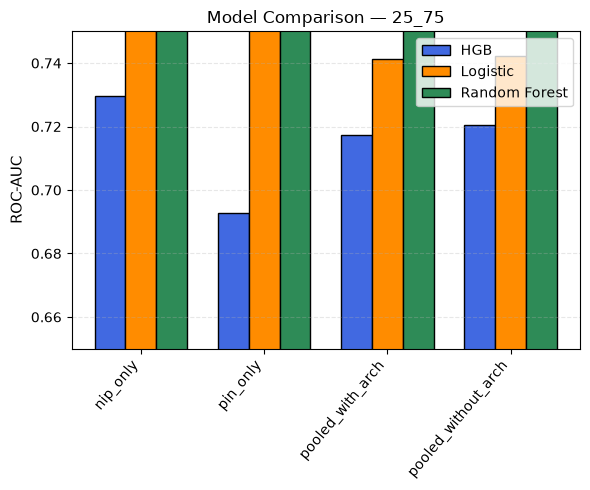

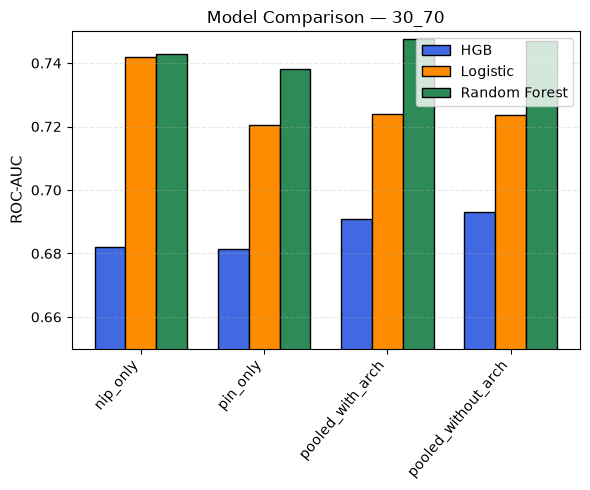

In [14]:
df_plot = pivot.reset_index()

dataset_order = ["nip_only", "pin_only", "pooled_with_arch", "pooled_without_arch"]

for setting in sorted(df_plot["setting"].unique()):
    tmp = df_plot[df_plot["setting"] == setting].copy()
    tmp["dataset"] = pd.Categorical(tmp["dataset"], categories=dataset_order, ordered=True)
    tmp = tmp.sort_values("dataset")

    x = np.arange(len(tmp))
    width = 0.25
    plt.figure(figsize=(6,5))

    bars1 = plt.bar(x - width, tmp["hgb"], width=width, color="royalblue", edgecolor="black", label="HGB")
    bars2 = plt.bar(x, tmp["logistic"], width=width, color="darkorange", edgecolor="black", label="Logistic")
    bars3 = plt.bar(x + width, tmp["rf"], width=width, color="seagreen", edgecolor="black", label="Random Forest")

    plt.xticks(x, tmp["dataset"], rotation=50, ha="right")
    plt.ylabel("ROC-AUC", fontsize=11)
    plt.title(f"Model Comparison — {setting}")

    plt.ylim(0.65, 0.75) 

    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()

    plt.savefig(os.path.join(ARTIFACT_DIR, f"model_comparison_{setting}.png"), dpi=600)
    plt.show()

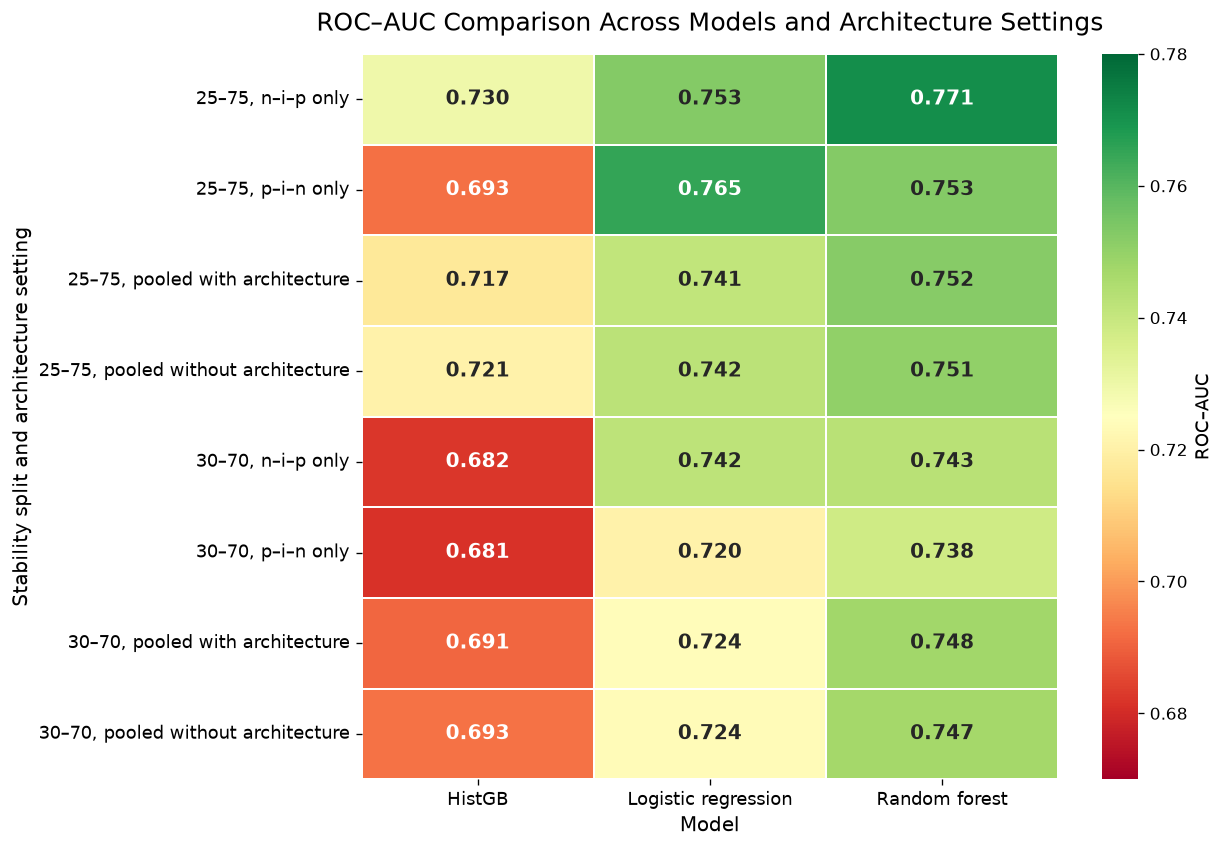

Saved:
C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\06D_architecture_cls\Figure5_FINAL_architecture_heatmap.png
C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\06D_architecture_cls\Figure5_FINAL_architecture_heatmap.pdf


In [24]:
# ============================================================
# FINAL FIGURE 5
# Architecture-specific classification heatmap
# Uses FINAL values directly from summary_df
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Build heatmap directly from final summary_df
# ------------------------------------------------------------

heatmap_df = summary_df.pivot_table(
    index=["setting", "dataset"],
    columns="model",
    values="roc_auc_mean"
)

# Exact order for publication
row_order = [
    ("25_75", "nip_only"),
    ("25_75", "pin_only"),
    ("25_75", "pooled_with_arch"),
    ("25_75", "pooled_without_arch"),
    ("30_70", "nip_only"),
    ("30_70", "pin_only"),
    ("30_70", "pooled_with_arch"),
    ("30_70", "pooled_without_arch"),
]

heatmap_df = heatmap_df.loc[row_order]

# Model order
heatmap_df = heatmap_df[
    ["hgb", "logistic", "rf"]
]

heatmap_df = heatmap_df.rename(
    columns={
        "hgb": "HistGB",
        "logistic": "Logistic regression",
        "rf": "Random forest"
    }
)

# Cleaner row names
row_labels = [
    "25–75, n–i–p only",
    "25–75, p–i–n only",
    "25–75, pooled with architecture",
    "25–75, pooled without architecture",
    "30–70, n–i–p only",
    "30–70, p–i–n only",
    "30–70, pooled with architecture",
    "30–70, pooled without architecture"
]

# ------------------------------------------------------------
# 2. Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10.5, 7.2)
)

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    vmin=0.67,
    vmax=0.78,
    linewidths=1.2,
    linecolor="white",
    cbar_kws={"label": "ROC–AUC"},
    annot_kws={
        "fontsize": 12,
        "fontweight": "bold"
    },
    ax=ax
)

ax.set_yticklabels(
    row_labels,
    rotation=0,
    fontsize=11
)

ax.set_xticklabels(
    ["HistGB", "Logistic regression", "Random forest"],
    rotation=0,
    fontsize=11
)

ax.set_xlabel(
    "Model",
    fontsize=12
)

ax.set_ylabel(
    "Stability split and architecture setting",
    fontsize=12
)

ax.set_title(
    "ROC–AUC Comparison Across Models and Architecture Settings",
    fontsize=15,
    pad=14
)

plt.tight_layout()

# ------------------------------------------------------------
# 3. Save publication-quality files
# ------------------------------------------------------------

fig5_png = os.path.join(
    ARTIFACT_DIR,
    "Figure5_FINAL_architecture_heatmap.png"
)

fig5_pdf = os.path.join(
    ARTIFACT_DIR,
    "Figure5_FINAL_architecture_heatmap.pdf"
)

fig.savefig(
    fig5_png,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    fig5_pdf,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:")
print(fig5_png)
print(fig5_pdf)

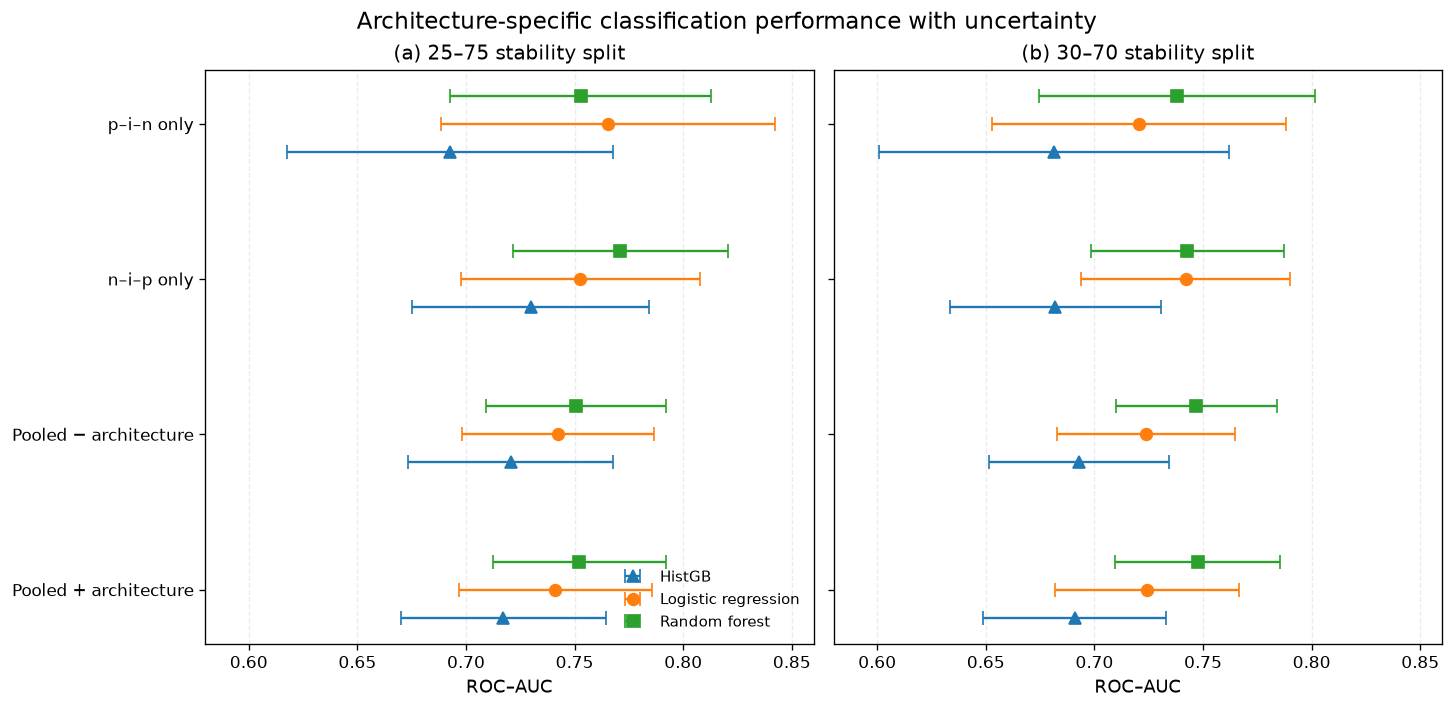

Saved:
C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\06D_architecture_cls\FigureS6_FINAL_architecture_uncertainty.png
C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\06D_architecture_cls\FigureS6_FINAL_architecture_uncertainty.pdf


In [25]:
# ============================================================
# FINAL FIGURE S6
# Architecture-specific classification performance
# Mean ROC-AUC ± SD across 30 DOI-grouped splits
# Complementary to Figure 5 heatmap
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

dataset_order = [
    "pooled_with_arch",
    "pooled_without_arch",
    "nip_only",
    "pin_only"
]

dataset_labels = [
    "Pooled + architecture",
    "Pooled − architecture",
    "n–i–p only",
    "p–i–n only"
]

model_order = [
    "hgb",
    "logistic",
    "rf"
]

model_labels = {
    "hgb": "HistGB",
    "logistic": "Logistic regression",
    "rf": "Random forest"
}

markers = {
    "hgb": "^",
    "logistic": "o",
    "rf": "s"
}

settings_plot = [
    ("25_75", "25–75 stability split"),
    ("30_70", "30–70 stability split")
]

# Small vertical offsets separate the three models
offsets = {
    "hgb": -0.18,
    "logistic": 0.00,
    "rf": 0.18
}

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5.8),
    sharey=True,
    constrained_layout=True
)

y_base = np.arange(len(dataset_order))

for ax, (setting, title) in zip(axes, settings_plot):

    sub = summary_df[
        summary_df["setting"] == setting
    ].copy()

    for model in model_order:

        model_sub = (
            sub[sub["model"] == model]
            .set_index("dataset")
            .loc[dataset_order]
            .reset_index()
        )

        means = model_sub["roc_auc_mean"].to_numpy()
        stds = model_sub["roc_auc_std"].to_numpy()

        y_pos = y_base + offsets[model]

        ax.errorbar(
            means,
            y_pos,
            xerr=stds,
            fmt=markers[model],
            markersize=7,
            capsize=4,
            linewidth=1.6,
            elinewidth=1.4,
            label=model_labels[model]
        )

    ax.set_yticks(y_base)
    ax.set_yticklabels(
        dataset_labels,
        fontsize=10
    )

    ax.set_xlim(
        0.58,
        0.86
    )

    ax.set_xlabel(
        "ROC–AUC",
        fontsize=11
    )

    panel = "a" if setting == "25_75" else "b"

    ax.set_title(
        f"({panel}) {title}",
        fontsize=12
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)

# Put legend once only
axes[0].legend(
    frameon=False,
    loc="lower right",
    fontsize=9
)

fig.suptitle(
    "Architecture-specific classification performance with uncertainty",
    fontsize=14
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

figS6_png = os.path.join(
    ARTIFACT_DIR,
    "FigureS6_FINAL_architecture_uncertainty.png"
)

figS6_pdf = os.path.join(
    ARTIFACT_DIR,
    "FigureS6_FINAL_architecture_uncertainty.pdf"
)

fig.savefig(
    figS6_png,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    figS6_pdf,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:")
print(figS6_png)
print(figS6_pdf)

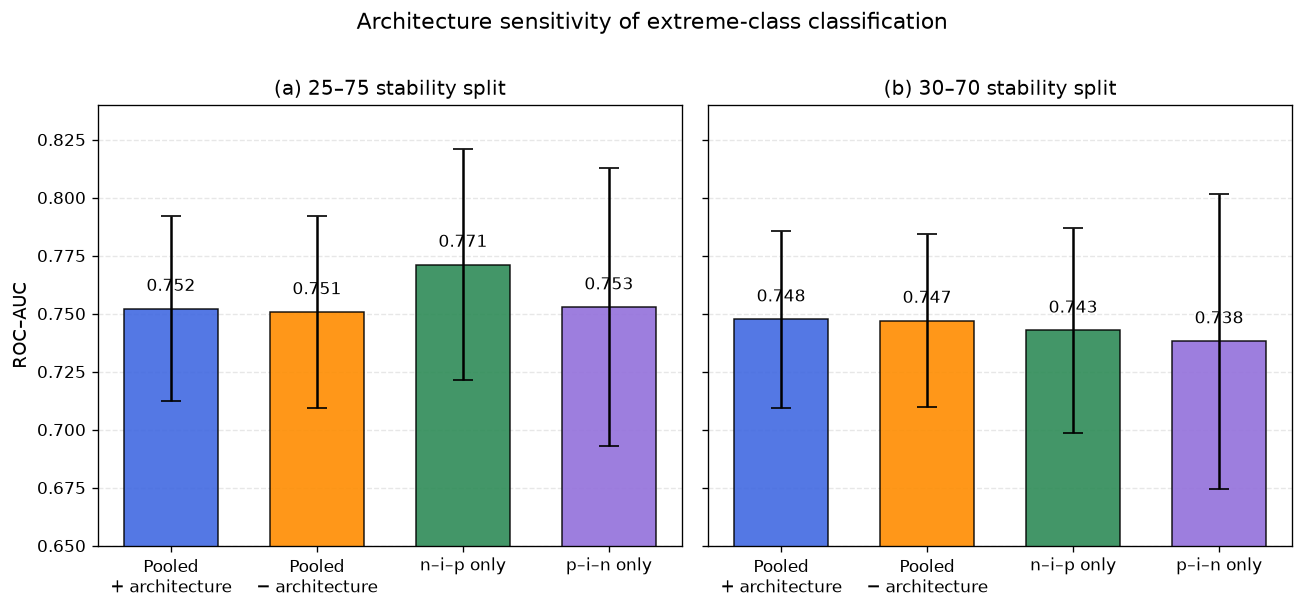

Saved:
C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\06D_architecture_cls\Figure5_FINAL_architecture_sensitivity.png
C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\06D_architecture_cls\Figure5_FINAL_architecture_sensitivity.pdf


In [19]:
# ============================================================
# FINAL FIGURE 5 — OLD BAR-CHART STYLE
# Architecture sensitivity of Random Forest classifier
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

dataset_order = [
    "pooled_with_arch",
    "pooled_without_arch",
    "nip_only",
    "pin_only"
]

dataset_labels = [
    "Pooled\n+ architecture",
    "Pooled\n− architecture",
    "n–i–p only",
    "p–i–n only"
]

bar_colors = [
    "royalblue",
    "darkorange",
    "seagreen",
    "mediumpurple"
]

settings_plot = [
    ("25_75", "25–75 stability split"),
    ("30_70", "30–70 stability split")
]

fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 5),
    sharey=True
)

for ax, (setting, title) in zip(axes, settings_plot):

    sub = summary_df[
        (summary_df["setting"] == setting) &
        (summary_df["model"] == "rf")
    ].copy()

    sub = (
        sub.set_index("dataset")
        .loc[dataset_order]
        .reset_index()
    )

    means = sub["roc_auc_mean"].to_numpy()
    stds = sub["roc_auc_std"].to_numpy()

    x = np.arange(len(dataset_order))

    bars = ax.bar(
        x,
        means,
        yerr=stds,
        capsize=6,
        width=0.64,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.9,
        alpha=0.9
    )

    # numerical labels
    for bar, mean in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            mean + 0.006,
            f"{mean:.3f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        dataset_labels,
        fontsize=10
    )

    ax.set_title(
        f"({'a' if setting == '25_75' else 'b'}) {title}",
        fontsize=12
    )

    ax.set_ylim(0.65, 0.84)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    ax.set_axisbelow(True)

axes[0].set_ylabel(
    "ROC–AUC",
    fontsize=11
)

fig.suptitle(
    "Architecture sensitivity of extreme-class classification",
    fontsize=13,
    y=1.01
)

plt.tight_layout()

# Save
fig5_png = os.path.join(
    ARTIFACT_DIR,
    "Figure5_FINAL_architecture_sensitivity.png"
)

fig5_pdf = os.path.join(
    ARTIFACT_DIR,
    "Figure5_FINAL_architecture_sensitivity.pdf"
)

plt.savefig(
    fig5_png,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    fig5_pdf,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(fig5_png)
print(fig5_pdf)

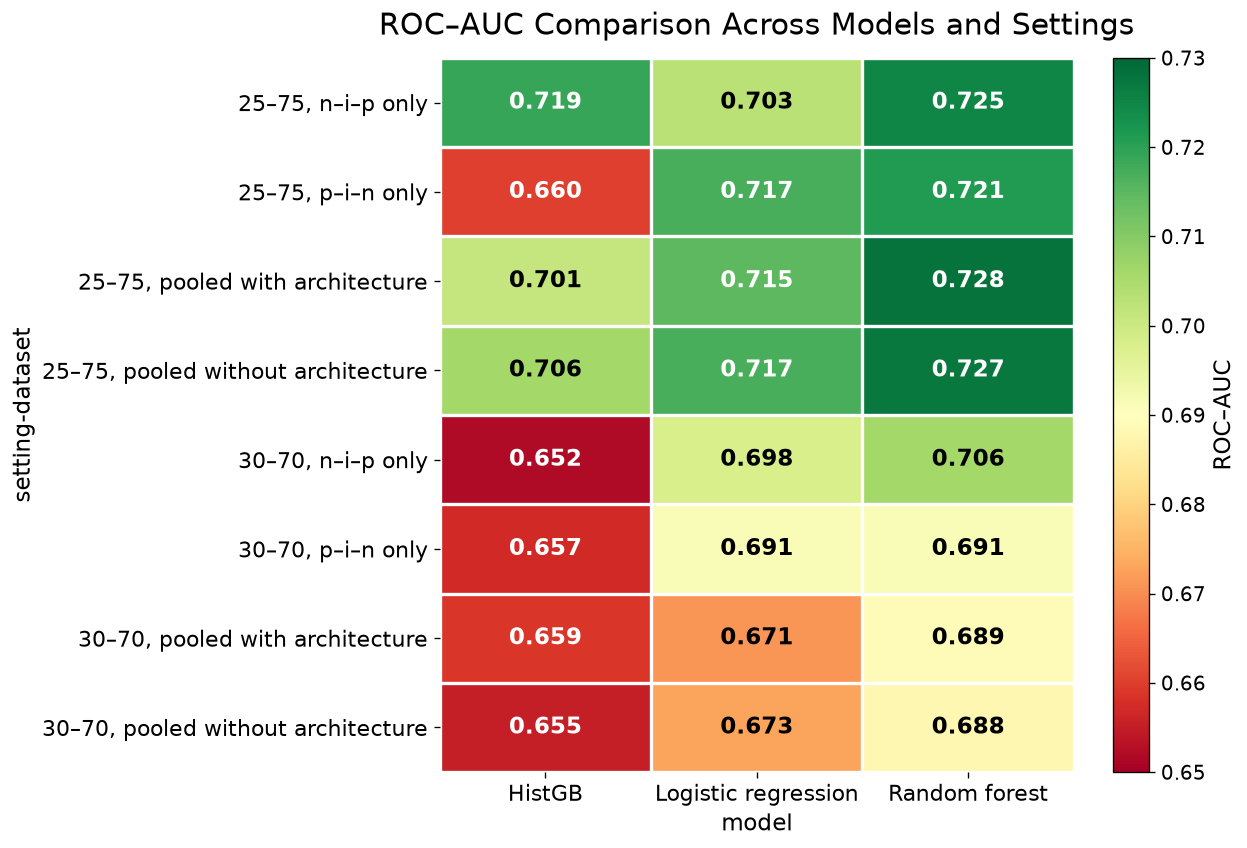

Saved:
C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\06D_architecture_cls\Figure5_FINAL_architecture_heatmap.png
C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\06D_architecture_cls\Figure5_FINAL_architecture_heatmap.pdf


In [23]:
# ============================================================
# FINAL FIGURE S6 — OLD HEATMAP STYLE
# Full model × architecture comparison
# ============================================================

import os
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------
# Build table
# -----------------------------------------

pivot_final = summary_df.pivot_table(
    index=["setting", "dataset"],
    columns="model",
    values="roc_auc_mean"
)

row_order = [
    ("25_75", "nip_only"),
    ("25_75", "pin_only"),
    ("25_75", "pooled_with_arch"),
    ("25_75", "pooled_without_arch"),
    ("30_70", "nip_only"),
    ("30_70", "pin_only"),
    ("30_70", "pooled_with_arch"),
    ("30_70", "pooled_without_arch"),
]

pivot_final = pivot_final.loc[row_order]

# Rename model columns
pivot_final = pivot_final.rename(
    columns={
        "hgb": "HistGB",
        "logistic": "Logistic regression",
        "rf": "Random forest"
    }
)

# Cleaner row labels
clean_labels = [
    "25–75 | n–i–p only",
    "25–75 | p–i–n only",
    "25–75 | pooled + architecture",
    "25–75 | pooled − architecture",
    "30–70 | n–i–p only",
    "30–70 | p–i–n only",
    "30–70 | pooled + architecture",
    "30–70 | pooled − architecture"
]


# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10.5, 7.2))

im = ax.imshow(
    heatmap_data,
    cmap="RdYlGn",      # red -> yellow -> green
    vmin=0.65,
    vmax=0.73,
    aspect="auto"
)

# Axis ticks and labels
ax.set_xticks(np.arange(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=13)

ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=13)

# Title and axis labels
ax.set_title(
    "ROC–AUC Comparison Across Models and Settings",
    fontsize=18,
    pad=14
)
ax.set_xlabel("model", fontsize=14)
ax.set_ylabel("setting-dataset", fontsize=14)

# ------------------------------------------------------------
# 4. Annotate each cell
# ------------------------------------------------------------
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data[i, j]

        # white text on darker cells, black on lighter cells
        text_color = "white" if (value <= 0.665 or value >= 0.715) else "black"

        ax.text(
            j, i,
            f"{value:.3f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=14,
            fontweight="bold"
        )

# ------------------------------------------------------------
# 5. Cell borders for cleaner look
# ------------------------------------------------------------
ax.set_xticks(np.arange(-0.5, len(col_labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

# Remove outer spines
for spine in ax.spines.values():
    spine.set_visible(False)

# ------------------------------------------------------------
# 6. Colorbar
# ------------------------------------------------------------
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("ROC–AUC", fontsize=14)
cbar.ax.tick_params(labelsize=12)

# ------------------------------------------------------------
# 7. Save
# ------------------------------------------------------------
plt.tight_layout()

png_path = os.path.join(ARTIFACT_DIR, "Figure5_FINAL_architecture_heatmap.png")
pdf_path = os.path.join(ARTIFACT_DIR, "Figure5_FINAL_architecture_heatmap.pdf")

fig.savefig(png_path, dpi=600, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

plt.show()

print("Saved:")
print(png_path)
print(pdf_path)

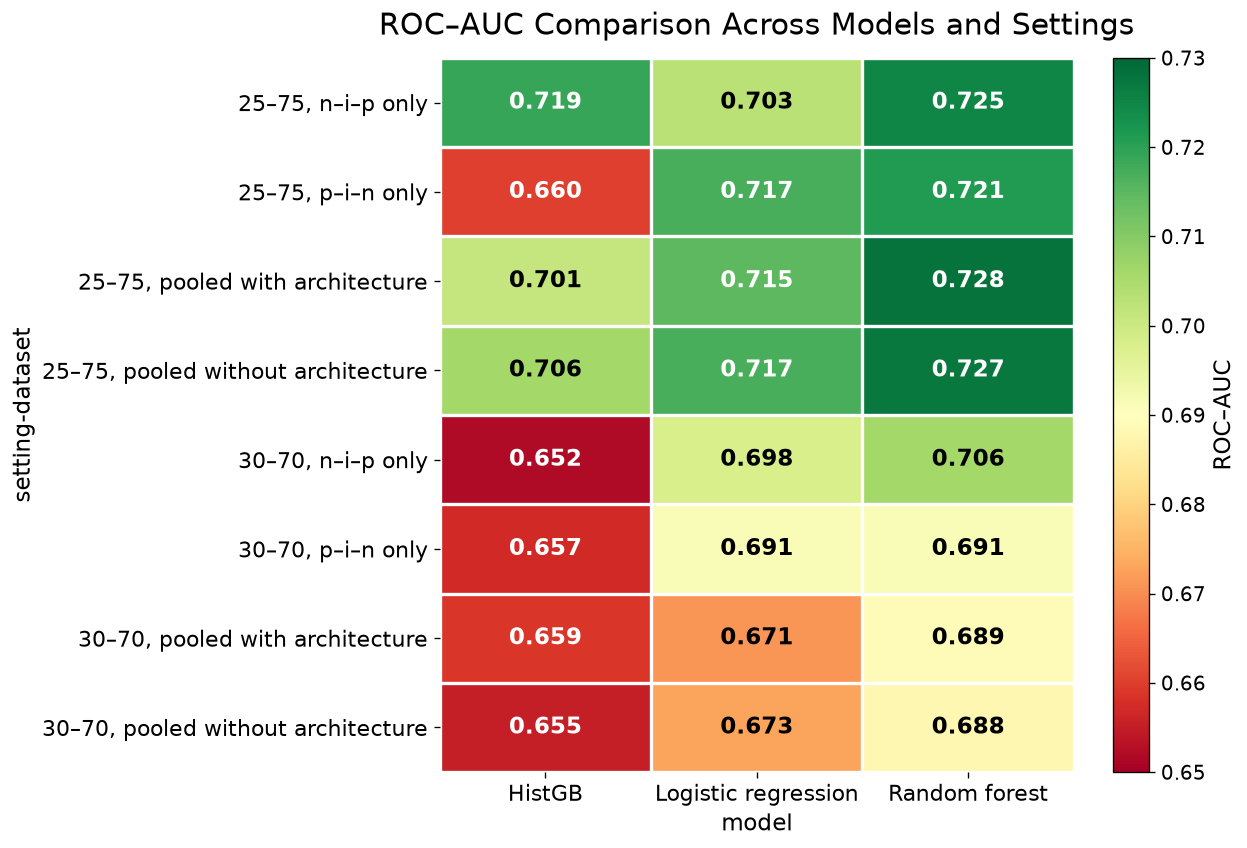

Saved:
C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\06D_architecture_cls\Figure5_FINAL_architecture_heatmap.png
C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\06D_architecture_cls\Figure5_FINAL_architecture_heatmap.pdf


In [22]:

# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10.5, 7.2))

im = ax.imshow(
    heatmap_data,
    cmap="RdYlGn",      # red -> yellow -> green
    vmin=0.65,
    vmax=0.73,
    aspect="auto"
)

# Axis ticks and labels
ax.set_xticks(np.arange(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=13)

ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=13)

# Title and axis labels
ax.set_title(
    "ROC–AUC Comparison Across Models and Settings",
    fontsize=18,
    pad=14
)
ax.set_xlabel("model", fontsize=14)
ax.set_ylabel("setting-dataset", fontsize=14)

# ------------------------------------------------------------
# 4. Annotate each cell
# ------------------------------------------------------------
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data[i, j]

        # white text on darker cells, black on lighter cells
        text_color = "white" if (value <= 0.665 or value >= 0.715) else "black"

        ax.text(
            j, i,
            f"{value:.3f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=14,
            fontweight="bold"
        )

# ------------------------------------------------------------
# 5. Cell borders for cleaner look
# ------------------------------------------------------------
ax.set_xticks(np.arange(-0.5, len(col_labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

# Remove outer spines
for spine in ax.spines.values():
    spine.set_visible(False)

# ------------------------------------------------------------
# 6. Colorbar
# ------------------------------------------------------------
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("ROC–AUC", fontsize=14)
cbar.ax.tick_params(labelsize=12)

# ------------------------------------------------------------
# 7. Save
# ------------------------------------------------------------
plt.tight_layout()

png_path = os.path.join(ARTIFACT_DIR, "Figure5_FINAL_architecture_heatmap.png")
pdf_path = os.path.join(ARTIFACT_DIR, "Figure5_FINAL_architecture_heatmap.pdf")

fig.savefig(png_path, dpi=600, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

plt.show()

print("Saved:")
print(png_path)
print(pdf_path)